In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_county_candidate = pd.read_csv("data/president_county_candidate.csv")
df_county = pd.read_csv("data/president_county.csv")
df_senate_candidate = pd.read_csv("data/senate_county_candidate.csv")

df_merged = pd.merge(df_county_candidate, df_county, on=["state", "county"], how="left")
df_merged2 = pd.merge(df_merged, df_senate_candidate, on=["state", "county"], how="left")
display(df_merged2)

,state,county,candidate_x,party_x,total_votes_x,won,current_votes,total_votes_y,percent,candidate_y,party_y,total_votes
0,Delaware,Kent County,Joe Biden,DEM,44552,True,87025,87025,100,Lauren Witzke,REP,38571.0
1,Delaware,Kent County,Joe Biden,DEM,44552,True,87025,87025,100,Mark Turley,IPD,1553.0
2,Delaware,Kent County,Joe Biden,DEM,44552,True,87025,87025,100,Nadine Frost,LIB,958.0
3,Delaware,Kent County,Donald Trump,REP,41009,False,87025,87025,100,Lauren Witzke,REP,38571.0
4,Delaware,Kent County,Donald Trump,REP,41009,False,87025,87025,100,Mark Turley,IPD,1553.0
...,...,...,...,...,...,...,...,...,...,...,...,...
102641,Arizona,Mohave County,Joe Biden,DEM,24831,False,104705,104705,100,Write-ins,WRI,49.0
102642,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False,104705,104705,100,Mark Kelly,DEM,27414.0
102643,Arizona,Mohave County,Jo Jorgensen,LIB,1302,False,104705,104705,100,Write-ins,WRI,49.0
102644,Arizona,Mohave County,Write-ins,WRI,37,False,104705,104705,100,Mark Kelly,DEM,27414.0


In [2]:
senate_winners = df_senate_candidate.loc[df_senate_candidate.groupby(['state', 'county'])['total_votes'].idxmax()][['state', 'county', 'party']].copy()
senate_winners.rename(columns = {'party': 'senate_party'}, inplace=True)

presidential_winners = df_county_candidate[df_county_candidate['won'] == True][['state', 'county', 'party']].copy()
presidential_winners.rename(columns={'party': 'party'}, inplace=True)

# Merge presidential and senate winners
winners_merged = pd.merge(presidential_winners, senate_winners, on=['state', 'county'], how= 'left')


# Filter only for  Georgia
georgia_data = winners_merged[winners_merged['state'] == 'Georgia'].copy()
georgia_data = georgia_data.reset_index(drop=True)

display(georgia_data)

,state,county,party,senate_party
0,Georgia,Appling County,REP,REP
1,Georgia,Atkinson County,REP,REP
2,Georgia,Bacon County,REP,REP
3,Georgia,Baker County,REP,DEM
4,Georgia,Baldwin County,DEM,DEM
...,...,...,...,...
154,Georgia,Whitfield County,REP,DEM
155,Georgia,Wilcox County,REP,REP
156,Georgia,Wilkes County,REP,DEM
157,Georgia,Wilkinson County,REP,DEM


In [3]:
georgia_data['vote_alignment'] = np.where(
   georgia_data['party'] == georgia_data['senate_party'],
   "Both " + georgia_data['party'],
   "Split"
)
display(georgia_data)

,state,county,party,senate_party,vote_alignment
0,Georgia,Appling County,REP,REP,Both REP
1,Georgia,Atkinson County,REP,REP,Both REP
2,Georgia,Bacon County,REP,REP,Both REP
3,Georgia,Baker County,REP,DEM,Split
4,Georgia,Baldwin County,DEM,DEM,Both DEM
...,...,...,...,...,...
154,Georgia,Whitfield County,REP,DEM,Split
155,Georgia,Wilcox County,REP,REP,Both REP
156,Georgia,Wilkes County,REP,DEM,Split
157,Georgia,Wilkinson County,REP,DEM,Split


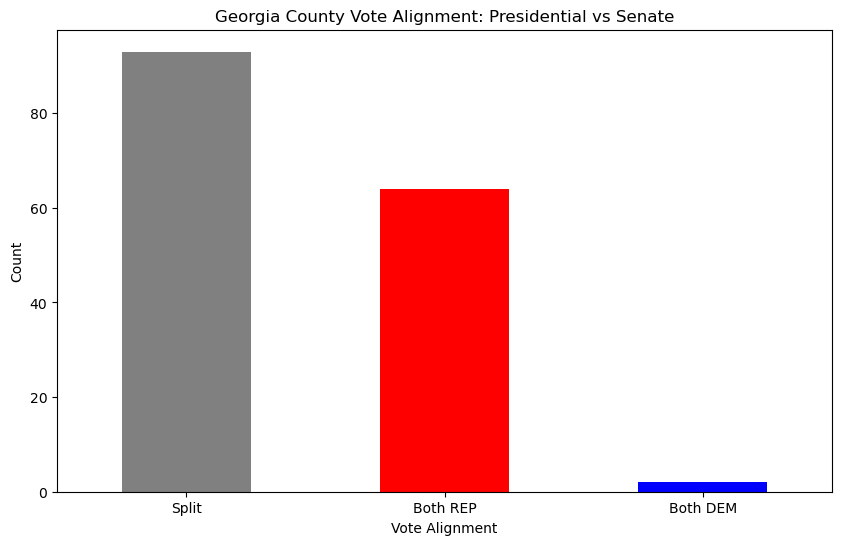

In [4]:
color_map = {
    'Both DEM': 'blue',
    'Both REP': 'red',
    'Split': 'gray'
}

colors = [color_map.get(val, 'gray') for val in georgia_data['vote_alignment'].value_counts().index]

georgia_data['vote_alignment'].value_counts().plot(kind='bar', figsize=(10, 6), color = colors)
plt.xlabel('Vote Alignment')
plt.ylabel('Count')
plt.title('Georgia County Vote Alignment: Presidential vs Senate')
plt.xticks(rotation=0)
plt.show()


In [5]:
#Split D/R or R/D / Both Dem / Both Rep
def classify_split(row):
   if row['party'] == row['senate_party']:
       if row['party'] == 'DEM':
           return "Both Democrat"
       elif row['party'] == 'REP':
           return "Both Republican"
       else:
           return "Both Other"
   else:
       if row['party'] == 'DEM' and row['senate_party'] == 'REP':
           return "Pres DEM / Senate REP"
       elif row['party'] == 'REP' and row['senate_party'] == 'DEM':
           return "Pres REP / Senate DEM"
       else:
           return "Other Split"


georgia_data['vote_alignment'] = georgia_data.apply(classify_split, axis=1)


#Counting each
alignment_counts = georgia_data['vote_alignment'].value_counts().reset_index()
alignment_counts.columns = ['vote_alignment', 'count']
display(alignment_counts)

#Counting each
alignment_counts = georgia_data['vote_alignment'].value_counts().reset_index()
alignment_counts.columns = ['vote_alignment', 'count']
display(alignment_counts)


,vote_alignment,count
0,Pres REP / Senate DEM,65
1,Both Republican,64
2,Pres DEM / Senate REP,28
3,Both Democrat,2


,vote_alignment,count
0,Pres REP / Senate DEM,65
1,Both Republican,64
2,Pres DEM / Senate REP,28
3,Both Democrat,2


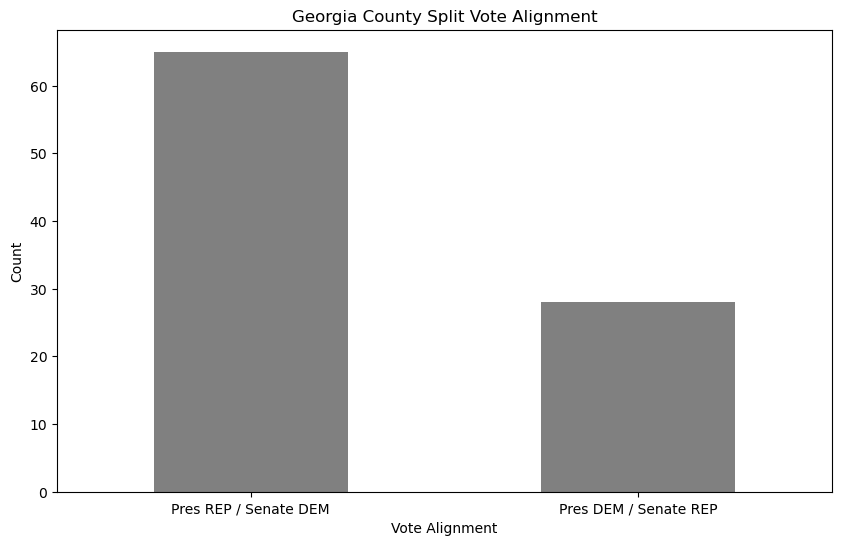

In [6]:
split_alignment = alignment_counts[alignment_counts['vote_alignment'].str.contains('Pres', na=False)]
split_alignment.plot(x='vote_alignment', y='count', kind='bar', figsize=(10, 6), legend=False, color = "gray")
plt.xlabel('Vote Alignment')
plt.ylabel('Count')
plt.title('Georgia County Split Vote Alignment')
plt.xticks(rotation=0)
plt.show()